In [1]:
import os
import pandas as pd
import re
import numpy as np
import GEO_to_XYcenter as xysar
import matplotlib.pyplot as plt
import xarray as xr

In [2]:
sargeo_modif_df = pd.read_csv("excels/SARGEO_modifiee.csv")   #chemin vers le csv du sargeo modifiée (liée avec le listing du sar)
sargeo_df = pd.read_csv("excels/SARGEO_cyclones.csv")                   #chemin vers le csv du sargeo
sar_list_df = pd.read_csv("excels/listing_res_3km.csv")           #chemin vers le csv du listing sar
sargeo_modif_df.fillna(0, inplace=True)
sargeo_modif_df.head(1)

,cyclone,canal,fichier,lat_centre,lon_centre,sar_acquisition_time,sar_xy,sar_inter,sar_path
0,al102019,IRWIN,s1a-iw-owi-cm-20190920t221952-20190920t222132-...,19.548832,298.289185,"2019-09-20T22:19:52,000",0,s1a-iw-owi-cm-20190920t221837-20190920t222132-...,/home/datawork-cersat-public/cache/public/ftp/...


In [ ]:
sar_folder = "/scale/user/mtannaou/alternance/donnees_sar"      #chemin vers le dossier content les fichiers netcdf des SAR
output_dir = "/scale/user/mtannaou/alternance/donnees_sar_changes_update"         #chemin d output




# df_copy_sar_files = sargeo_modif_df[sargeo_modif_df[sargeo_modif_df.columns[-1]]!=0].copy()
# for file_path in df_copy_sar_files[df_copy_sar_files.columns[-1]]:
#     try:
#         xysar.convert_sar_to_xy(file_path, sargeo_modif_df, output_dir)
#     except Exception as e:
#         print(f"❌ Erreur pour {file_path}: {e}")

In [3]:
len(os.listdir("donnees_sar_changes"))

1243

In [13]:
i = 0
lim = False


/tmp/ipykernel_2127552/3082356917.py:9: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_geo = xr.open_dataset(sargeo_path+"/"+cyclone_name+"/IRWIN/"+geo_exemple_file_path)


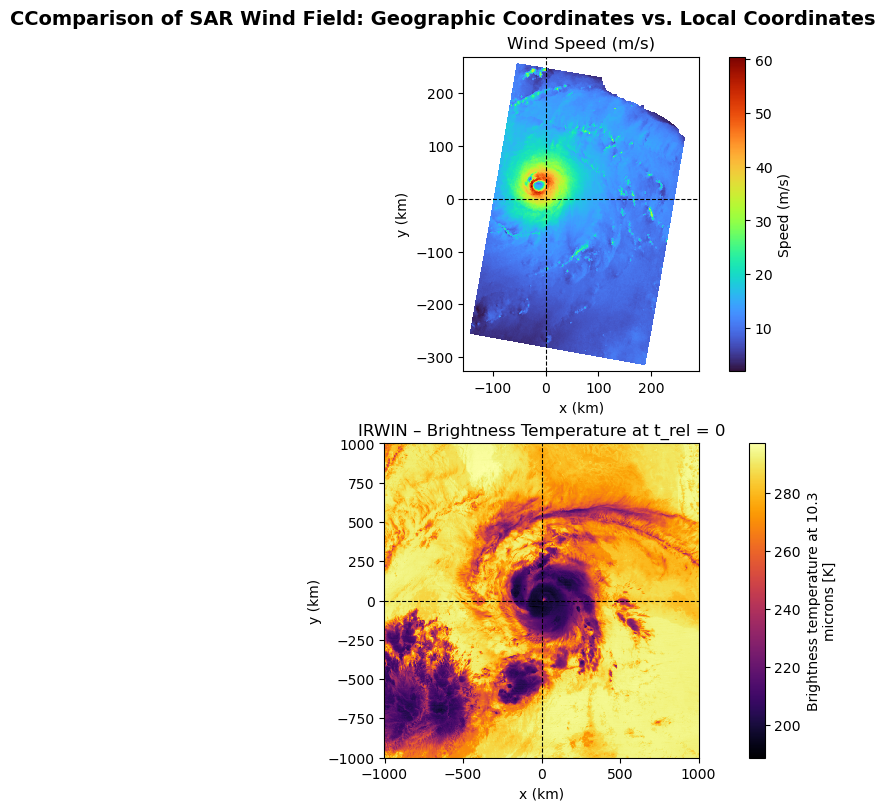

In [14]:
# Création de la figure
i = i+1
sargeo_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs"
row = sargeo_modif_df[sargeo_modif_df["sar_xy"] != 0].iloc[i]
sar_xy_exemple_file_path = row["sar_xy"]
cyclone_name = row["cyclone"]
geo_exemple_file_path = row["fichier"]
ds_sar_xy = xr.open_dataset(sar_xy_exemple_file_path)
ds_geo = xr.open_dataset(sargeo_path+"/"+cyclone_name+"/IRWIN/"+geo_exemple_file_path)
fig, axes = plt.subplots(2, 1, figsize=(8, 8), constrained_layout=True)

im11 = axes[0].pcolormesh(
    ds_sar_xy["x_sar"], ds_sar_xy["y_sar"],
    ds_sar_xy["owiWindSpeed"], cmap="turbo", shading='auto',
)
axes[0].set_title(f"Wind Speed (m/s)", fontsize=12)
axes[0].set_xlabel("x (km)")
axes[0].set_ylabel("y (km)")
axes[0].set_aspect('equal', adjustable='box') 
axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)
if lim : 
    axes[0].set_xlim(-1000,1000)
    axes[0].set_ylim(-1000,1000)
cbar11 = fig.colorbar(im11, ax=axes[0], orientation="vertical", pad=0.02)
cbar11.set_label("Speed (m/s)", rotation=90)

#image GEO 
ds_geo["IRWIN"].sel(t_rel=0).plot.imshow(cmap='inferno', ax=axes[1])
axes[1].set_title(f"IRWIN – Brightness Temperature at t_rel = 0")
axes[1].set_xlabel("x (km)")
axes[1].set_ylabel("y (km)")
axes[1].set_aspect('equal', adjustable='box') 
axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)

# --- Ajustement global ---
fig.suptitle("CComparison of SAR Wind Field: Geographic Coordinates vs. Local Coordinates", fontsize=14, fontweight='bold')
plt.show()

4 fichiers de alexis mouche a visuliser

/tmp/ipykernel_958494/1522517888.py:27: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_sar = xr.open_dataset(path_sar_geo)


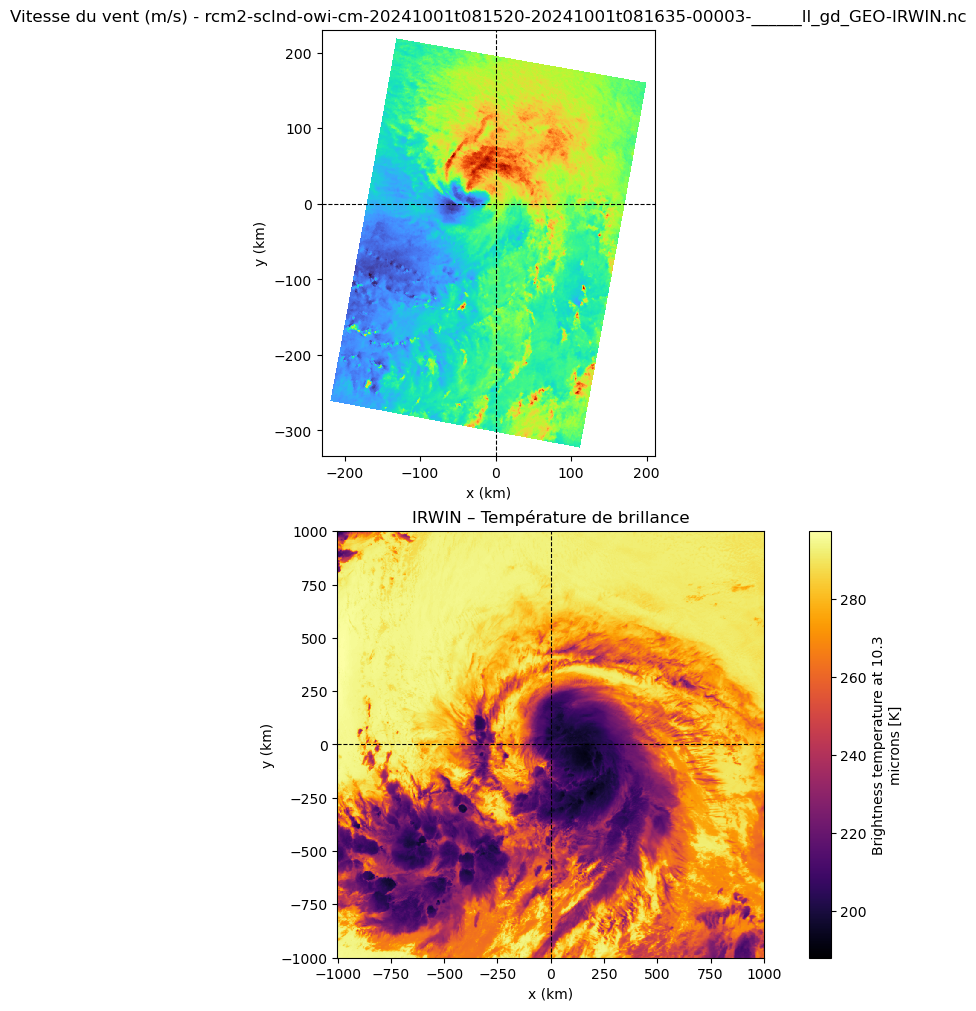

In [ ]:
# import os
# import pandas as pd
# import re
# import numpy as np
# import GEO_to_XYcenter as xysar
# import matplotlib.pyplot as plt
# import xarray as xr

# indice = 3
# sar_listes = ['/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-1/L2M/sclnc/rcm-1_sclnc/2024/278/RCM1_OK3296938_PK3300253_1_SCLNC_20241004_212519_VV_VH_GRD/rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-xxxxx.nc'
# ,'/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/sentinel-1a/L2M/EW/S1A_EW_GRDM_1S/2024/276/S1A_EW_GRDM_1SDV_20241002T083611_20241002T083727_055921_06D630_56DC/s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630.nc'
# ,'/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-1/L2M/sclnc/rcm-1_sclnc/2024/281/RCM1_OK3302881_PK3304982_1_SCLNC_20241007_201755_VV_VH_GRD/rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-xxxxx.nc'
# ,'/home/datawork-cersat-public/cache/public/ftp/project/sarwing/processings/grdwind+windir_2025v6v12_2v0_0v3v9_0v0v6_0v0v6_1v4v3_1v0v15_1v0v10_1v2v5_1v2v2_1v1v1_1v2v1/cmod5n_ecmwf_norecal_rs2rcmgmfv4_28052025/rcm-2/L2M/sclnd/rcm-2_sclnd/2024/275/RCM2_OK3292643_PK3293960_1_SCLND_20241001_081522_VV_VH_GRD/rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-xxxxx.nc']

# geo_paths = ["rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-______ll_gd_GEO-IRWIN.nc",
#              "s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630_ll_gd_GEO-IRWIN.nc",
#              "rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-______ll_gd_GEO-IRWIN.nc",
#              "rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-______ll_gd_GEO-IRWIN.nc"
#              ]
# xy_path = ["/scale/user/mtannaou/alternance/dossier_mouche_/rcm1-sclnc-owi-cm-20241004t212518-20241004t212636-00003-xxxxx_aeqd.nc"
#            ,"/scale/user/mtannaou/alternance/dossier_mouche_/s1a-ew-owi-cm-20241002t083611-20241002t083727-000003-06D630_aeqd.nc"
#            ,"/scale/user/mtannaou/alternance/dossier_mouche_/rcm1-sclnc-owi-cm-20241007t201754-20241007t201912-00003-xxxxx_aeqd.nc"
#            ,"/scale/user/mtannaou/alternance/dossier_mouche_/rcm2-sclnd-owi-cm-20241001t081520-20241001t081635-00003-xxxxx_aeqd.nc"]

# path_global_irwin = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs/al122024/IRWIN"

# path_sar_geo = path_global_irwin+"/"+geo_paths[indice]
# ds_sar = xr.open_dataset(path_sar_geo)
# ds_geo = ds_sar
# ds_xy = xr.open_dataset(xy_path[indice])
# # print(ds_sar)
# fig, axes = plt.subplots(2, 1, figsize=(7, 10), constrained_layout=True)
# im11 = axes[0].pcolormesh(
#     ds_xy["x_sar"], ds_xy["y_sar"],
#     ds_xy["owiWindSpeed"], cmap="turbo", shading='auto',
# )
# axes[0].set_title(f"Vitesse du vent (m/s) - {geo_paths[indice]}", fontsize=12)
# axes[0].set_xlabel("x (km)")
# axes[0].set_ylabel("y (km)")
# axes[0].set_aspect('equal', adjustable='box') 
# axes[0].axhline(0, color='black', linestyle='--', linewidth=0.8)
# axes[0].axvline(0, color='black', linestyle='--', linewidth=0.8)

# ds_geo["IRWIN"].sel(t_rel=0).plot.imshow(cmap='inferno', ax=axes[1])
# axes[1].set_title(f"IRWIN – Température de brillance")
# axes[1].set_xlabel("x (km)")
# axes[1].set_ylabel("y (km)")
# axes[1].set_aspect('equal', adjustable='box') 
# axes[1].axhline(0, color='black', linestyle='--', linewidth=0.8)
# axes[1].axvline(0, color='black', linestyle='--', linewidth=0.8)



Verification de décalage du centre

In [29]:
sargeo_df = pd.read_csv("excels/SARGEO_modifiee.csv")
ind = 1
sar_path = sargeo_df["sar_path"].loc[ind]
file_path_sargeo = sargeo_df["fichier"].loc[ind]
cyclone_name = sargeo_df["cyclone"].loc[ind]
canal = sargeo_df["canal"].loc[ind]
sargeo_path = "/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs"
base_name = os.listdir(os.path.join(sargeo_path,cyclone_name,canal))[0]
file_path = os.path.join(sargeo_path,cyclone_name,canal,base_name)
file_path

'/scale/project/ifremer-isi-jumeaunumerique/SARGEO/prototype/v01r02/cyclobs/al012024/IRWIN/rcm1-sclnd-owi-cm-20240620t004603-20240620t004719-00003-______ll_gd_GEO-IRWIN.nc'

In [32]:
ds_sargeo = xr.open_dataset(file_path)
ds_sar = xr.open_dataset(sar_path)
print(ds_sar.data_vars.keys())
len(ds_sar.data_vars.keys())

KeysView(Data variables:
    owiLon                             (owiAzSize, owiRaSize) float64 1MB ...
    owiElevationAngle                  (owiAzSize, owiRaSize) float64 1MB ...
    owiHeading                         (owiAzSize, owiRaSize) float32 738kB ...
    owiLat                             (owiAzSize, owiRaSize) float64 1MB ...
    owiLandFlag                        (owiAzSize, owiRaSize) int8 185kB ...
    owiOffboresightAngle               (owiAzSize, owiRaSize) float64 1MB ...
    owiIncidenceAngle                  (owiAzSize, owiRaSize) float32 738kB ...
    owiMask                            (owiAzSize, owiRaSize) int8 185kB ...
    owiAncillaryWindDirection          (owiAzSize, owiRaSize) float64 1MB ...
    owiAncillaryWindSpeed              (owiAzSize, owiRaSize) float64 1MB ...
    owiNrcs_detrend                    (owiAzSize, owiRaSize) float64 1MB ...
    owiNrcs_detrend_cross              (owiAzSize, owiRaSize) float64 1MB ...
    owiNesz_cross_flattened          

/tmp/ipykernel_2127552/445154786.py:1: FutureWarning: In a future version, xarray will not decode the variable 'time_diff' into a timedelta64 dtype based on the presence of a timedelta-like 'units' attribute by default. Instead it will rely on the presence of a timedelta64 'dtype' attribute, which is now xarray's default way of encoding timedelta64 values.
To continue decoding into a timedelta64 dtype, either set `decode_timedelta=True` when opening this dataset, or add the attribute `dtype='timedelta64[ns]'` to this variable on disk.
To opt-in to future behavior, set `decode_timedelta=False`.
  ds_sargeo = xr.open_dataset(file_path)


31